In [24]:
from langgraph.graph import StateGraph ,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated
from typing_extensions import TypedDict

from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv 

In [26]:
memory=InMemorySaver()

In [8]:
class State(TypedDict):
    message:Annotated[list ,add_messages]

In [4]:
llm=ChatMistralAI(model_name="mistral-small-latest")

In [10]:
# Node Functionality 
def chatbot(state:State):
    return {"message":[llm.invoke(state['message'])]}

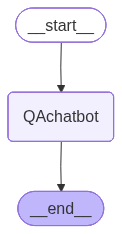

In [13]:
# Building Graph
builder=StateGraph(State)
builder.add_node("QAchatbot",chatbot)

builder.add_edge(START,"QAchatbot")
builder.add_edge("QAchatbot",END)
builder.compile()

In [29]:
graph=builder.compile(checkpointer=memory)

In [16]:
response=graph.invoke({"message":"My name is Devi"})

In [18]:
print(response['message'][-1].content)

That’s a lovely name! Devi is a common name in many cultures, often associated with strength and divinity. How can I assist you today? 😊


In [19]:
response2=graph.invoke({"message":"What is my name ?"})

In [20]:
print(response2['message'][-1].content)

I don't have access to personal information about you unless you've shared it with me previously. If you've provided your name in our conversation, I can refer to it. Otherwise, I don't know your name.


> I don't have access to personal information about you unless you've shared it with me previously. If you've provided your name in our conversation, I can refer to it. Otherwise, I don't know your name. [SO we have to use Memory]

In [27]:
# Config thread ID
config={"configurable":{"thread_id":'1'}}

In [33]:
response3=graph.invoke({"message":"My Name is Devidutta"},config=config)

In [34]:
print(response3['message'][-1].content)

Nice to meet you, Devidutta! 😊 How can I help you today?


In [36]:
response4=graph.invoke({"message":"What is my name ?"},config=config)

In [37]:
print(response4['message'][-1].content)

Your name is **Devidutta**! 😊

(If you'd like me to call you something else or need help with something, just let me know!)
